# 최종 결과 확인

모델 1과 모델 2를 결합한 최종 결과를 확인하는 노트북입니다.

최종 점수는 아래처럼 계산합니다.

```text
최종위험도점수 = 사고발생확률_p * 조건부위험도_r
최종위험도점수_percent = 최종위험도점수 / max(최종위험도점수) * 100
```

최종 시각화 대상은 아래 조건입니다.

```text
위험도_actual = 0
AND 최종위험도점수_percent > 50
```

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

VENV_PYTHON = PROJECT_ROOT / ".venv" / "bin" / "python"
PYTHON = VENV_PYTHON if VENV_PYTHON.exists() else Path(sys.executable)

RESULT_PATH = PROJECT_ROOT / "artifacts" / "predictions" / "two_stage_zero_risk_predictions.csv"
CLASSIFIER_MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "mlp_accident_classifier_notebook.keras"
REGRESSOR_MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "mlp_positive_risk_regressor_notebook.keras"
PREDICT_SCRIPT_PATH = PROJECT_ROOT / "scripts" / "predict" / "predict_two_stage_zero_risk.py"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RESULT_PATH: {RESULT_PATH.relative_to(PROJECT_ROOT)}")

PROJECT_ROOT: /home/huichan/SPARV/SilverWalk
RESULT_PATH: artifacts/predictions/two_stage_zero_risk_predictions.csv


In [2]:
def make_tensorflow_env() -> dict[str, str]:
    """TensorFlow subprocess가 pip NVIDIA CUDA 라이브러리를 찾도록 환경변수를 구성합니다."""
    env = os.environ.copy()
    site_packages_candidates = list((PROJECT_ROOT / ".venv" / "lib").glob("python*/site-packages"))
    nvidia_lib_dirs = []
    for site_packages in site_packages_candidates:
        nvidia_root = site_packages / "nvidia"
        if nvidia_root.exists():
            nvidia_lib_dirs.extend(str(path) for path in nvidia_root.rglob("lib") if path.is_dir())

    existing_ld_path = env.get("LD_LIBRARY_PATH", "")
    ld_parts = [*nvidia_lib_dirs, "/usr/lib/wsl/lib"]
    if existing_ld_path:
        ld_parts.append(existing_ld_path)
    env["LD_LIBRARY_PATH"] = ":".join(dict.fromkeys(part for part in ld_parts if part))
    return env


tensorflow_env = make_tensorflow_env()

In [3]:
required_paths = {
    "result_csv": RESULT_PATH,
    "classifier_model": CLASSIFIER_MODEL_PATH,
    "regressor_model": REGRESSOR_MODEL_PATH,
    "predict_script": PREDICT_SCRIPT_PATH,
}

path_status = []
for name, path in required_paths.items():
    path_status.append(
        {
            "name": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else None,
        }
    )

display(pd.DataFrame(path_status))

,name,path,exists,size_mb
0,result_csv,artifacts/predictions/two_stage_zero_risk_pred...,True,35.30
1,classifier_model,artifacts/models/mlp_accident_classifier_noteb...,True,0.32
2,regressor_model,artifacts/models/mlp_positive_risk_regressor_n...,True,0.32
3,predict_script,scripts/predict/predict_two_stage_zero_risk.py,True,0.01


In [4]:
# 결과 CSV가 없거나 다시 생성하고 싶으면 RUN_PREDICTION = True로 바꿔 실행합니다.
RUN_PREDICTION = False

if RUN_PREDICTION or not RESULT_PATH.exists():
    cmd = [
        str(PYTHON),
        str(PREDICT_SCRIPT_PATH),
        "--classifier-model-path", str(CLASSIFIER_MODEL_PATH),
        "--regressor-model-path", str(REGRESSOR_MODEL_PATH),
        "--output", str(RESULT_PATH),
        "--device", "auto",
    ]
    print("실행 명령:")
    print(" ".join(cmd))

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        env=tensorflow_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"최종 결과 생성 실패: exit code {return_code}")
else:
    print("기존 최종 결과 CSV를 사용합니다.")

기존 최종 결과 CSV를 사용합니다.


In [5]:
result = pd.read_csv(RESULT_PATH)
print("결과 크기:", result.shape)
display(result.head())

required_columns = [
    "POINT_ID",
    "위도",
    "경도",
    "위험도_actual",
    "사고발생확률_p",
    "조건부위험도_r",
    "최종위험도점수",
    "최종위험도점수_percent",
]
missing = [column for column in required_columns if column not in result.columns]
if missing:
    raise ValueError(f"최종 결과 CSV에 필요한 컬럼이 없습니다: {missing}")

if (result["위험도_actual"] != 0).any():
    raise ValueError("최종 결과에 위험도_actual이 0이 아닌 행이 포함되어 있습니다.")

결과 크기: (360787, 9)


,POINT_ID,위도,경도,위험도_actual,사고발생확률_p,조건부위험도_log1p_r,조건부위험도_r,최종위험도점수,최종위험도점수_percent
0,0,37.591080,126.992864,0.0,0.002729,0.505428,0.657695,0.001795,0.003811
1,1,37.590982,126.992616,0.0,0.002190,0.495881,0.641945,0.001406,0.002985
2,2,37.590820,126.992421,0.0,0.002549,0.379022,0.460854,0.001175,0.002494
3,3,37.590660,126.992225,0.0,0.003132,0.561074,0.752553,0.002357,0.005004
4,4,37.590492,126.992037,0.0,0.004695,0.479836,0.615810,0.002891,0.006139


In [6]:
summary = {
    "rows": len(result),
    "위험도_actual != 0 rows": int((result["위험도_actual"] != 0).sum()),
    "최종위험도점수_percent > 50": int((result["최종위험도점수_percent"] > 50).sum()),
    "최종위험도점수_percent > 70": int((result["최종위험도점수_percent"] > 70).sum()),
    "최종위험도점수_percent > 90": int((result["최종위험도점수_percent"] > 90).sum()),
    "max 사고발생확률_p": result["사고발생확률_p"].max(),
    "max 조건부위험도_r": result["조건부위험도_r"].max(),
    "max 최종위험도점수": result["최종위험도점수"].max(),
}

display(pd.DataFrame([summary]))

,rows,위험도_actual != 0 rows,최종위험도점수_percent > 50,최종위험도점수_percent > 70,최종위험도점수_percent > 90,max 사고발생확률_p,max 조건부위험도_r,max 최종위험도점수
0,360787,0,7,1,1,0.98934,48.502235,47.099186


In [7]:
score_columns = ["사고발생확률_p", "조건부위험도_r", "최종위험도점수", "최종위험도점수_percent"]
display(result[score_columns].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).T)

,count,mean,std,min,50%,75%,90%,95%,99%,99.9%,max
사고발생확률_p,360787.0,0.136517,0.174701,8.248682e-07,0.061024,0.185254,0.393620,0.536101,0.762317,0.907929,0.989340
조건부위험도_r,360787.0,0.825839,0.882783,0.000000e+00,0.671697,0.963191,1.386754,1.855446,3.897424,10.349383,48.502235
최종위험도점수,360787.0,0.137733,0.418091,0.000000e+00,0.036788,0.123325,0.324568,0.548558,1.469629,4.984152,47.099186
최종위험도점수_percent,360787.0,0.292432,0.887683,0.000000e+00,0.078108,0.261841,0.689115,1.164688,3.120285,10.582247,100.000000


In [8]:
high_risk = result[result["최종위험도점수_percent"] > 50].sort_values(
    "최종위험도점수_percent",
    ascending=False,
)

print("50% 초과 포인트 수:", len(high_risk))
display(
    high_risk[
        [
            "POINT_ID",
            "위도",
            "경도",
            "위험도_actual",
            "사고발생확률_p",
            "조건부위험도_r",
            "최종위험도점수",
            "최종위험도점수_percent",
        ]
    ]
)

50% 초과 포인트 수: 7


,POINT_ID,위도,경도,위험도_actual,사고발생확률_p,조건부위험도_r,최종위험도점수,최종위험도점수_percent
43866,52904,37.547712,127.023405,0.0,0.971073,48.502235,47.099186,100.000000
193215,243096,37.548586,126.957106,0.0,0.685689,46.230240,31.699587,67.303894
193102,242976,37.548528,126.957365,0.0,0.708962,43.754833,31.020512,65.862100
187626,236719,37.548532,126.957369,0.0,0.712232,43.202343,30.770073,65.330370
531,645,37.572140,127.014180,0.0,0.908155,33.251620,30.197622,64.114960
249,327,37.572131,127.014071,0.0,0.953110,29.532152,28.147396,59.761960
193181,243062,37.548686,126.957223,0.0,0.731026,37.949300,27.741915,58.901047


In [9]:
top_n = 50
top_result = result.sort_values("최종위험도점수_percent", ascending=False).head(top_n)
display(
    top_result[
        [
            "POINT_ID",
            "위도",
            "경도",
            "사고발생확률_p",
            "조건부위험도_r",
            "최종위험도점수",
            "최종위험도점수_percent",
        ]
    ]
)

,POINT_ID,위도,경도,사고발생확률_p,조건부위험도_r,최종위험도점수,최종위험도점수_percent
43866,52904,37.547712,127.023405,0.971073,48.502235,47.099186,100.000000
193215,243096,37.548586,126.957106,0.685689,46.230240,31.699587,67.303894
193102,242976,37.548528,126.957365,0.708962,43.754833,31.020512,65.862100
187626,236719,37.548532,126.957369,0.712232,43.202343,30.770073,65.330370
531,645,37.572140,127.014180,0.908155,33.251620,30.197622,64.114960
249,327,37.572131,127.014071,0.953110,29.532152,28.147396,59.761960
193181,243062,37.548686,126.957223,0.731026,37.949300,27.741915,58.901047
216441,272528,37.560980,126.853889,0.787322,29.543707,23.260424,49.386044
193216,243097,37.548575,126.957146,0.604183,35.272450,21.311022,45.247112
70197,84638,37.577649,127.034952,0.926244,21.669277,20.071040,42.614410


/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71053/2363453091.py:13: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt

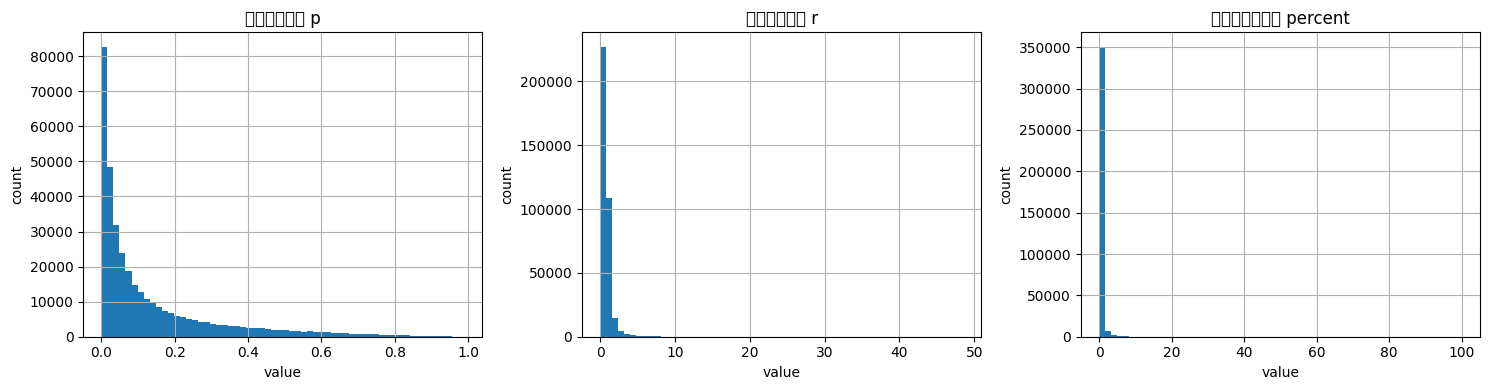

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
result["사고발생확률_p"].hist(ax=axes[0], bins=60)
axes[0].set_title("사고발생확률 p")
result["조건부위험도_r"].hist(ax=axes[1], bins=60)
axes[1].set_title("조건부위험도 r")
result["최종위험도점수_percent"].hist(ax=axes[2], bins=60)
axes[2].set_title("최종위험도점수 percent")
for ax in axes:
    ax.set_xlabel("value")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

In [11]:
# 지도 시각화에 넘길 최소 컬럼만 따로 확인합니다.
map_points = high_risk[["POINT_ID", "위도", "경도", "최종위험도점수_percent", "최종위험도점수"]].copy()
display(map_points)

,POINT_ID,위도,경도,최종위험도점수_percent,최종위험도점수
43866,52904,37.547712,127.023405,100.000000,47.099186
193215,243096,37.548586,126.957106,67.303894,31.699587
193102,242976,37.548528,126.957365,65.862100,31.020512
187626,236719,37.548532,126.957369,65.330370,30.770073
531,645,37.572140,127.014180,64.114960,30.197622
249,327,37.572131,127.014071,59.761960,28.147396
193181,243062,37.548686,126.957223,58.901047,27.741915
